In [67]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Dict, Optional
from scipy.special import lpmv, gammaln  # associated Legendre + stable factorial logs


C_KMS = 299792.458  # speed of light [km/s]


# -----------------------------
# Limb darkening (linear)
# -----------------------------
def limb_darkening_linear(mu: np.ndarray, u_lambda: float) -> np.ndarray:
    """
    Linear limb darkening: h(mu) = 1 - u (1 - mu).
    mu = cos(theta') in [0, 1] over visible hemisphere.
    """
    return 1.0 - u_lambda * (1.0 - mu)


# -----------------------------
# Intrinsic profile interface
# -----------------------------
def gaussian_intrinsic_profile(lam: np.ndarray,
                               lam_center: np.ndarray,
                               sigma_lam: float) -> np.ndarray:
    """
    Gaussian intrinsic profile in wavelength space:
      (1 / sqrt(2pi) sigma) * exp(-(lam_center - lam)^2 / (2 sigma^2))

    Parameters
    ----------
    lam : (Nlam,)
    lam_center : (...,)  (e.g. per-surface-element centers)
    sigma_lam : float (wavelength units, same as lam)
    """
    # broadcast: (..., 1) - (1, Nlam) -> (..., Nlam)
    x = (lam_center[..., None] - lam[None, :]) / sigma_lam
    return np.exp(-0.5 * x * x) / (np.sqrt(2.0 * np.pi) * sigma_lam)


# -----------------------------
# Geometry: visible hemisphere grid
# -----------------------------
@dataclass(frozen=True)
class VisibleHemisphereGrid:
    theta: np.ndarray     # (Ntheta,) theta' in [0, pi/2]
    phi: np.ndarray       # (Nphi,)   phi'   in [0, 2pi)
    TH: np.ndarray        # (Ntheta, Nphi) mesh
    PH: np.ndarray        # (Ntheta, Nphi) mesh
    mu: np.ndarray        # (Ntheta, Nphi) = cos(theta')
    sinTH: np.ndarray     # (Ntheta, Nphi) = sin(theta')
    dtheta: float
    dphi: float


def make_visible_hemisphere_grid(n_theta: int = 180, n_phi: int = 360) -> VisibleHemisphereGrid:
    """
    Builds (theta', phi') grid on visible hemisphere:
      theta' ∈ [0, pi/2], phi' ∈ [0, 2pi)
    Using uniform steps in theta', phi' as per the book’s practical guidance.
    """
    theta = np.linspace(0.0, 0.5 * np.pi, n_theta, endpoint=False) + (0.5*np.pi)/n_theta/2
    phi = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=False) + (2*np.pi)/n_phi/2

    dtheta = (0.5 * np.pi) / n_theta
    dphi = (2.0 * np.pi) / n_phi

    TH, PH = np.meshgrid(theta, phi, indexing="ij")
    mu = np.cos(TH)
    sinTH = np.sin(TH)

    return VisibleHemisphereGrid(theta=theta, phi=phi, TH=TH, PH=PH, mu=mu, sinTH=sinTH,
                                 dtheta=dtheta, dphi=dphi)


# -----------------------------
# Associated Legendre P_l^k and derivative w.r.t theta'
# -----------------------------
def _P_lk(l: int, k: int, x: np.ndarray) -> np.ndarray:
    eps = 1e-12
    x = np.clip(x, -1.0 + eps, 1.0 - eps)

    if k >= 0:
        out = lpmv(k, l, x)
        return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

    kp = -k
    P_pos = lpmv(kp, l, x)

    sign = -1.0 if (kp % 2) else 1.0
    log_fac = gammaln(l - kp + 1) - gammaln(l + kp + 1)

    out = np.zeros_like(P_pos, dtype=float)

    # Only log values that are finite AND non-zero
    absP = np.abs(P_pos)
    good = np.isfinite(P_pos) & (absP > 0.0)

    if np.any(good):
        log_abs = log_fac + np.log(absP[good])
        out_mag = np.exp(log_abs)
        out[good] = sign * out_mag * np.sign(P_pos[good])

    # Values where P_pos==0 stay 0, and non-finite stay 0
    return out


def dP_lk_dtheta(l: int, k: int, theta: np.ndarray) -> np.ndarray:
    x = np.cos(theta)
    s = np.sin(theta)

    eps = 1e-12
    x = np.clip(x, -1.0 + eps, 1.0 - eps)

    P_l = _P_lk(l, k, x)
    if l == 0:
        return np.zeros_like(theta)

    P_lm1 = _P_lk(l - 1, k, x)

    denom = (x * x - 1.0)
    denom = np.where(np.abs(denom) < 1e-14, np.sign(denom) * 1e-14, denom)

    dPdx = (l * x * P_l - (l + k) * P_lm1) / denom
    out = -s * dPdx
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


# -----------------------------
# a_{l m k}(i) transformation coefficient (Eq. 6.48)
# -----------------------------
def a_lmk(l: int, m: int, k: int, inc: float) -> float:
    """
    Implements the book’s coefficient a_{l m k}(i) (Eq. 6.48).

    Uses log-factorials via gammaln for numerical stability.

    Note: inc is inclination i in radians.
    """
    # prefactor sqrt((l+m)!(l-m)!)
    log_pref = 0.5 * (gammaln(l + m + 1) + gammaln(l - m + 1))
    pref = np.exp(log_pref)

    # summation limits
    r_min = max(0, k - m)
    r_max = min(l - m, l + k)

    s = 0.0
    sin_half = np.sin(inc / 2.0)
    cos_half = np.cos(inc / 2.0)

    for r in range(r_min, r_max + 1):
        # term ~ (-1)^(l-k+r) * sin(i/2)^(2l-2r-m+k) * cos(i/2)^(2r+m-k)
        sign = -1.0 if ((l - k + r) % 2) else 1.0
        p_sin = 2*l - 2*r - m + k
        p_cos = 2*r + m - k

        # denominator: r! (m-k+r)! (l-m-r)! (l+k-r)!
        log_den = (gammaln(r + 1) +
                   gammaln(m - k + r + 1) +
                   gammaln(l - m - r + 1) +
                   gammaln(l + k - r + 1))
        den = np.exp(log_den)

        s += sign * (sin_half ** p_sin) * (cos_half ** p_cos) / den

    return pref * s


# -----------------------------
# LOS velocity field v(R,theta',phi',t) (Eq. 6.46)
# -----------------------------
def los_velocity_field(grid: VisibleHemisphereGrid,
                       l: int, m: int,
                       omega: float, Omega: float,
                       inc: float,
                       K: float,
                       v_p: float,
                       v_sini: float,
                       t: float) -> np.ndarray:
    """
    Returns v(theta', phi', t) on the grid [km/s], following Eq. (6.46).
    - v_sini is the projected rotation speed v_Ω = Ω R sin i [km/s]
      (book denotes this often as v sin i).
    - v_p is the pulsation velocity amplitude scaling [km/s] (as defined in the book).
    """
    TH = grid.TH
    PH = grid.PH

    # Rotation contribution: - v_sini * sin(theta') * sin(phi')
    v_rot = -v_sini * grid.sinTH * np.sin(PH)

    # Pulsation contribution: sum over k = -l..l
    x = np.cos(TH)  # argument for P_l^k
    cosTH = np.cos(TH)
    sinTH = grid.sinTH

    v_puls = np.zeros_like(TH, dtype=float)

    # Precompute P_l^k and derivative pieces per k on the whole grid
    for k in range(-l, l + 1):
        a = a_lmk(l, m, k, inc)

        P = _P_lk(l, k, x)
        dP_dth = dP_lk_dtheta(l, k, TH)

        geom = (cosTH * P - K * sinTH * dP_dth)
        phase = np.sin((omega - m * Omega) * t + k * PH)

        v_puls += a * geom * phase

    v_puls *= v_p
    return v_rot + v_puls


# -----------------------------
# Line profile generator (Eq. 6.49)
# -----------------------------
def line_profile_p_lambda_t(lam: np.ndarray,
                            lam0: float,
                            grid: VisibleHemisphereGrid,
                            u_lambda: float,
                            intrinsic_profile: Callable[..., np.ndarray] = gaussian_intrinsic_profile,
                            intrinsic_params: Optional[Dict] = None,
                            v_field_kms: Optional[np.ndarray] = None,
                            sigma_intrinsic_kms: Optional[float] = None,
                            sigma_intrinsic_lam: Optional[float] = None) -> np.ndarray:
    """
    Computes p(lam, t) using Eq. (6.49) once a LOS velocity field v(theta',phi') is known.

    You can provide intrinsic width either as:
      - sigma_intrinsic_kms (velocity dispersion), converted via sigma_lam = lam0*sigma_v/c
      - sigma_intrinsic_lam (directly in wavelength units)

    intrinsic_profile is a pluggable callable:
      intrinsic_profile(lam, lam_center, **intrinsic_params) -> (..., Nlam)

    v_field_kms must be (Ntheta, Nphi).

    Returns
    -------
    p : (Nlam,) normalized line profile.
    """
    if intrinsic_params is None:
        intrinsic_params = {}

    if v_field_kms is None:
        raise ValueError("v_field_kms must be provided (LOS velocity field in km/s).")

    # Convert intrinsic width to wavelength units
    if sigma_intrinsic_lam is None:
        if sigma_intrinsic_kms is None:
            raise ValueError("Provide either sigma_intrinsic_kms or sigma_intrinsic_lam.")
        sigma_lam = lam0 * (sigma_intrinsic_kms / C_KMS)
    else:
        sigma_lam = float(sigma_intrinsic_lam)

    # Doppler-shifted central wavelength per surface element (Eq. 6.45)
    lam_center = lam0 * (1.0 + v_field_kms / C_KMS)  # (Ntheta, Nphi)

    # Weights: I0 cancels in normalization, so we omit it explicitly
    mu = grid.mu
    h = limb_darkening_linear(mu, u_lambda)

    # Discrete version of: R^2 sin(theta') cos(theta') dtheta dphi
    # R^2 cancels between numerator and denominator too, so omit it
    weights = h * np.sin(grid.TH) * np.cos(grid.TH) * grid.dtheta * grid.dphi  # (Ntheta, Nphi)

    # Intrinsic profile evaluated at each surface element’s Doppler center
    # Gaussian uses sigma_lam; we pass it via intrinsic_params for generality
    prof = intrinsic_profile(lam=lam, lam_center=lam_center, sigma_lam=sigma_lam, **intrinsic_params)  # (Ntheta,Nphi,Nlam)

    numerator = np.sum(weights[..., None] * prof, axis=(0, 1))
    denom = np.sum(weights)

    return numerator / denom


# -----------------------------
# High-level convenience: generate LPV time series
# -----------------------------
def generate_lpv_timeseries(lam: np.ndarray,
                            lam0: float,
                            times: np.ndarray,
                            l: int, m: int,
                            omega: float, Omega: float,
                            inc: float,
                            K: float,
                            v_p: float,
                            v_sini: float,
                            u_lambda: float,
                            sigma_intrinsic_kms: float,
                            n_theta: int = 180, n_phi: int = 360) -> np.ndarray:
    """
    Generates p(lam, t) over an array of times for a single (l,m) mode.
    Returns array with shape (Nt, Nlam).
    """
    grid = make_visible_hemisphere_grid(n_theta=n_theta, n_phi=n_phi)

    out = np.empty((times.size, lam.size), dtype=float)

    for it, t in enumerate(times):
        v = los_velocity_field(grid, l=l, m=m,
                               omega=omega, Omega=Omega,
                               inc=inc, K=K, v_p=v_p, v_sini=v_sini, t=float(t))

        out[it] = line_profile_p_lambda_t(
            lam=lam, lam0=lam0,
            
            grid=grid, u_lambda=u_lambda,
            intrinsic_profile=gaussian_intrinsic_profile,
            intrinsic_params={},
            v_field_kms=v,
            sigma_intrinsic_kms=sigma_intrinsic_kms
        )

    return out


In [83]:
# Wavelength grid around a line center
lam0 = 500.0  # nm (example)
lam = np.linspace(lam0 - 0.4, lam0 + 0.4, 801)

# Times to sample (seconds)
times = np.linspace(0.0, 2.0 * 12600.0, 30)

# Mode / star parameters
l, m = 5, 1
omega = 2*np.pi / (5*3600.0)     # pulsation angular frequency
Omega = 2*np.pi / (1.5*24*3600)  # rotation angular frequency
inc = np.deg2rad(60.0)

K = 2          # (keep as free for now; later you can plug sigma^{-2})
v_p = 2.0        # km/s pulsation amplitude scaling
v_sini = 50.0   # km/s
u_lambda = 0.4   # limb darkening coefficient
sigma_int = 5.0  # km/s intrinsic Gaussian width

profiles = generate_lpv_timeseries(
    lam=lam, lam0=lam0, times=times,
    l=l, m=m, omega=omega, Omega=Omega, inc=inc,
    K=K, v_p=v_p, v_sini=v_sini,
    u_lambda=u_lambda, sigma_intrinsic_kms=sigma_int,
    n_theta=180, n_phi=360
)

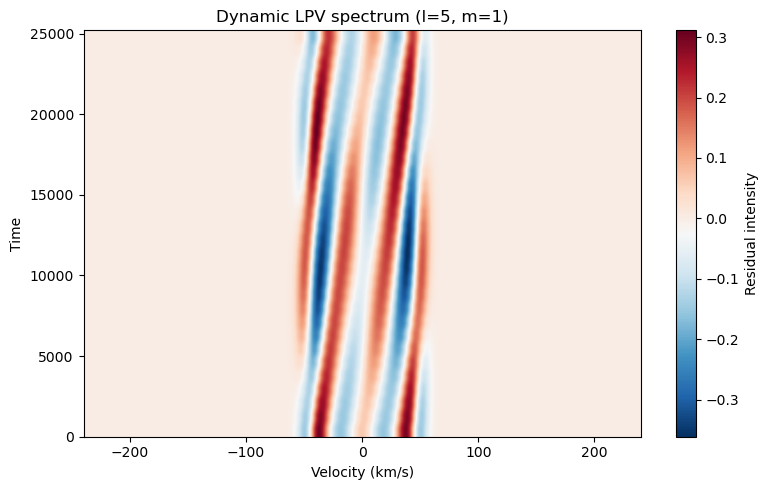

In [84]:
import numpy as np
import matplotlib.pyplot as plt

C_KMS = 299792.458

# Convert wavelength grid to velocity space
vel = C_KMS * (lam - lam0) / lam0

# Residual profiles (important to see bumps clearly)
residuals = profiles - np.mean(profiles, axis=0)

plt.figure(figsize=(8,5))

plt.imshow(residuals,
           aspect='auto',
           origin='lower',
           extent=[vel.min(), vel.max(), times.min(), times.max()],
           cmap='RdBu_r')
    
plt.colorbar(label='Residual intensity')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Time')
plt.title(f'Dynamic LPV spectrum (l={l}, m={m})')

plt.tight_layout()
plt.show()


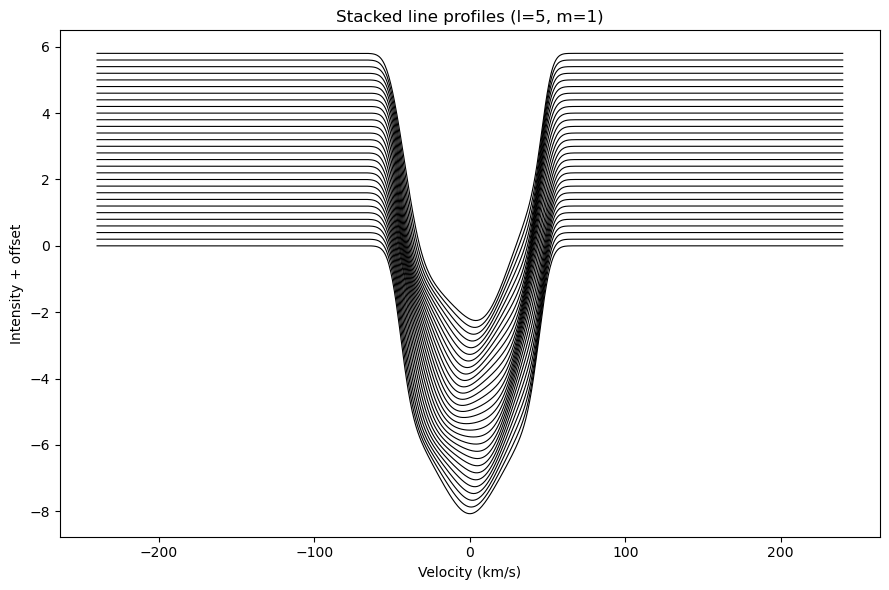

In [85]:
import numpy as np
import matplotlib.pyplot as plt

C_KMS = 299792.458
vel = C_KMS * (lam - lam0) / lam0  # km/s

offset = 0.2 # tweak this (bigger -> more separation)

plt.figure(figsize=(9,6))
for i in range(profiles.shape[0]):
    plt.plot(vel, -profiles[i] + i*offset, lw=0.8, c = 'k')

plt.xlabel("Velocity (km/s)")
plt.ylabel("Intensity + offset")
plt.title(f"Stacked line profiles (l={l}, m={m})")
plt.tight_layout()
plt.show()